# CRM Access Governance & Customer Data Protection
## Exploratory Data Analysis (EDA)

This notebook is the exploratory stage of the **CRM Access Governance & Customer Data Protection** project.

The dataset represents access events in a CRM environment and includes information about user roles, CRM actions, device types, access time, data sensitivity, permissions, login behavior, governance/risk scores, and the final access decision.

### EDA Objectives

1. Validate the structure and quality of the dataset.
2. Understand the distribution of numerical and categorical variables.
3. Analyze access behavior and potential risk factors.
4. Investigate the relationship between `Permission_Granted` and `Access_Decision`.
5. Identify factors associated with blocked or reviewed access attempts.
6. Explore interactions among role, action, device, data sensitivity, and user behavior.
7. Detect extreme values and unusual patterns.
8. Generate hypotheses for a future governance policy.
9. Prepare dimensions and metrics for the analytical model and Power BI dashboard.

> **Methodological note:** this is a synthetic dataset. Strong patterns may reflect rules used during data generation. At this stage, the goal is to observe and document these relationships without automatically treating them as real-world governance policies.

In [1]:
# 1. Libraries and Settings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = Path("Permission_Aware_CRM_Governance_Synthetic_50000.csv")

print("Environment ready.")


Environment ready.


# 2. Data Loading and Data Discovery

The first step is to understand the structure of the dataset before applying any transformations.

In [2]:
# 2.1 Data Loading

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Rows: 50,000
Columns: 15


,User_ID,Role,Region,Lead_Source,CRM_Action,Daily_Logins,Failed_Logins,Access_Hour,Device_Type,Data_Sensitivity,Policy_Compliance_Score,Anomaly_Score,Permission_Granted,Governance_Score,Access_Decision
0,1,Admin,North,Referral,ViewLead,6,1,10,Managed,5,76.19,0.11,True,51.81,Block
1,2,Sales Rep,West,Web,ViewLead,5,1,12,Managed,5,62.87,0.46,True,38.40,Block
2,3,Sales Rep,South,Partner,EditLead,6,1,20,Managed,1,81.87,0.08,False,48.57,Block
3,4,Analyst,South,Campaign,ViewLead,10,0,10,Managed,3,85.89,0.18,True,57.53,Block
4,5,Sales Rep,West,Web,EditLead,6,2,17,Managed,1,92.31,0.31,False,44.58,Block


In [3]:
# 2.2 Structure and Data Types

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User_ID                  50000 non-null  int64  
 1   Role                     50000 non-null  str    
 2   Region                   50000 non-null  str    
 3   Lead_Source              50000 non-null  str    
 4   CRM_Action               50000 non-null  str    
 5   Daily_Logins             50000 non-null  int64  
 6   Failed_Logins            50000 non-null  int64  
 7   Access_Hour              50000 non-null  int64  
 8   Device_Type              50000 non-null  str    
 9   Data_Sensitivity         50000 non-null  int64  
 10  Policy_Compliance_Score  50000 non-null  float64
 11  Anomaly_Score            50000 non-null  float64
 12  Permission_Granted       50000 non-null  bool   
 13  Governance_Score         50000 non-null  float64
 14  Access_Decision          50000 no

In [4]:
# 2.3 Structural Overview and Cardinality

structural_summary = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Non_Null": df.notna().sum(),
    "Nulls": df.isna().sum(),
    "Null_%": (df.isna().mean() * 100).round(2),
    "Unique_Values": df.nunique(),
    "Cardinality_%": (df.nunique() / len(df) * 100).round(2)
})

display(structural_summary)


,Data_Type,Non_Null,Nulls,Null_%,Unique_Values,Cardinality_%
User_ID,int64,50000,0,0.00,50000,100.00
Role,str,50000,0,0.00,5,0.01
Region,str,50000,0,0.00,4,0.01
Lead_Source,str,50000,0,0.00,5,0.01
CRM_Action,str,50000,0,0.00,6,0.01
Daily_Logins,int64,50000,0,0.00,21,0.04
Failed_Logins,int64,50000,0,0.00,7,0.01
Access_Hour,int64,50000,0,0.00,17,0.03
Device_Type,str,50000,0,0.00,2,0.00
Data_Sensitivity,int64,50000,0,0.00,5,0.01


In [5]:
# 2.4 Unique Values in Low-Cardinality Variables

low_cardinality_cols = [
    col for col in df.columns
    if df[col].nunique() <= 20
]

for col in low_cardinality_cols:
    print(f"\n{col} ({df[col].nunique()} unique values)")
    print(df[col].unique())



Role (5 unique values)
<StringArray>
['Admin', 'Sales Rep', 'Analyst', 'Support', 'Manager']
Length: 5, dtype: str

Region (4 unique values)
<StringArray>
['North', 'West', 'South', 'East']
Length: 4, dtype: str

Lead_Source (5 unique values)
<StringArray>
['Referral', 'Web', 'Partner', 'Campaign', 'Email']
Length: 5, dtype: str

CRM_Action (6 unique values)
<StringArray>
[         'ViewLead',          'EditLead', 'CreateOpportunity',
         'ExportCRM',        'DeleteLead',   'ApproveDiscount']
Length: 6, dtype: str

Failed_Logins (7 unique values)
[1 0 2 4 3 5 6]

Access_Hour (17 unique values)
[10 12 20 17 15  8 18 14  7 16 13 22 11 19  9 21  6]

Device_Type (2 unique values)
<StringArray>
['Managed', 'BYOD']
Length: 2, dtype: str

Data_Sensitivity (5 unique values)
[5 1 3 2 4]

Permission_Granted (2 unique values)
[ True False]

Access_Decision (2 unique values)
<StringArray>
['Block', 'Review']
Length: 2, dtype: str


## 2.5 Initial Data Dictionary

| Field | Interpretation | Analytical Category |
|---|---|---|
| `User_ID` | User identifier | Identifier |
| `Role` | User role/function | Access Control |
| `Region` | Region associated with the record | Dimension |
| `Lead_Source` | Commercial lead source | Dimension |
| `CRM_Action` | CRM action requested/performed | Activity |
| `Daily_Logins` | Number of daily logins | Behavior |
| `Failed_Logins` | Failed login attempts | Security |
| `Access_Hour` | Hour of access | Temporal Context |
| `Device_Type` | Device type | Security |
| `Data_Sensitivity` | Data sensitivity level | Governance |
| `Policy_Compliance_Score` | Policy compliance score | Governance |
| `Anomaly_Score` | Degree of anomalous behavior | Security |
| `Permission_Granted` | Whether functional permission exists | Authorization |
| `Governance_Score` | Aggregated governance score | Governance |
| `Access_Decision` | Final access outcome | Outcome |

This dictionary will later be refined into a formal **Data Classification Matrix**.

# 3. Data Quality Assessment

This section evaluates missing values, duplicate records, and basic domain consistency.

In [6]:
# 3.1 Missing Values

missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_Percentage", ascending=False)

display(missing)

print(f"Total missing values: {df.isna().sum().sum():,}")


,Missing_Count,Missing_Percentage
User_ID,0,0.00
Role,0,0.00
Region,0,0.00
Lead_Source,0,0.00
CRM_Action,0,0.00
Daily_Logins,0,0.00
Failed_Logins,0,0.00
Access_Hour,0,0.00
Device_Type,0,0.00
Data_Sensitivity,0,0.00


Total missing values: 0


In [7]:
# 3.2 Duplicate Records

duplicate_count = df.duplicated().sum()
duplicate_pct = duplicate_count / len(df) * 100

print(f"Duplicate records: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_pct:.2f}%")


Duplicate records: 0
Duplicate percentage: 0.00%


In [8]:
# 3.3 Domain Validation Checks

domain_checks = {
    "Access_Hour outside 0-23": (~df["Access_Hour"].between(0, 23)).sum(),
    "Data_Sensitivity outside 1-5": (~df["Data_Sensitivity"].between(1, 5)).sum(),
    "Anomaly_Score outside 0-1": (~df["Anomaly_Score"].between(0, 1)).sum(),
    "Policy_Compliance_Score outside 0-100": (~df["Policy_Compliance_Score"].between(0, 100)).sum(),
    "Governance_Score outside 0-100": (~df["Governance_Score"].between(0, 100)).sum(),
    "Daily_Logins negative values": (df["Daily_Logins"] < 0).sum(),
    "Failed_Logins negative values": (df["Failed_Logins"] < 0).sum()
}

display(pd.Series(domain_checks, name="Invalid_Records").to_frame())


,Invalid_Records
Access_Hour outside 0-23,0
Data_Sensitivity outside 1-5,0
Anomaly_Score outside 0-1,0
Policy_Compliance_Score outside 0-100,0
Governance_Score outside 0-100,0
Daily_Logins negative values,0
Failed_Logins negative values,0


# 4. Descriptive Analysis

Numerical and categorical variables are analyzed separately before investigating relationships among variables.

In [9]:
# 4.1 Numerical Variables

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
User_ID,"50,000.00","25,000.50","14,433.90",1.00,"12,500.75","25,000.50","37,500.25","50,000.00"
Daily_Logins,"50,000.00",6.01,2.44,0.00,4.00,6.00,8.00,20.00
Failed_Logins,"50,000.00",0.50,0.71,0.00,0.00,0.00,1.00,6.00
Access_Hour,"50,000.00",14.03,4.91,6.00,10.00,14.00,18.00,22.00
Data_Sensitivity,"50,000.00",3.01,1.42,1.00,2.00,3.00,4.00,5.00
Policy_Compliance_Score,"50,000.00",81.86,9.69,41.74,75.17,82.00,88.80,100.00
Anomaly_Score,"50,000.00",0.22,0.12,0.00,0.12,0.20,0.29,0.87
Governance_Score,"50,000.00",51.05,6.82,23.95,46.36,51.63,56.12,68.71


In [10]:
# 4.2 Categorical Variables

categorical_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()
display(df[categorical_cols].describe().T)


C:\Users\LeaoN\AppData\Local\Temp\ipykernel_27264\170461654.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()


,count,unique,top,freq
Role,50000,5,Sales Rep,20159
Region,50000,4,North,12577
Lead_Source,50000,5,Partner,10062
CRM_Action,50000,6,ViewLead,17696
Device_Type,50000,2,Managed,40035
Permission_Granted,50000,2,True,34069
Access_Decision,50000,2,Block,42072


# 5. Univariate Analysis — Categorical Variables

In addition to absolute frequency, this section examines the percentage distribution of each category.

In [11]:
# 5.1 Frequency Tables

for col in categorical_cols:
    frequency = (
        df[col]
        .value_counts(dropna=False)
        .to_frame("Count")
        .assign(Percentage=lambda x: (x["Count"] / len(df) * 100).round(2))
    )

    print(f"\n### {col}")
    display(frequency)



### Role


,Count,Percentage
Role,,
Sales Rep,20159,40.32
Manager,9904,19.81
Support,7566,15.13
Analyst,7389,14.78
Admin,4982,9.96



### Region


,Count,Percentage
Region,,
North,12577,25.15
South,12507,25.01
East,12466,24.93
West,12450,24.90



### Lead_Source


...

,Count,Percentage
Device_Type,,
Managed,40035,80.07
BYOD,9965,19.93



### Permission_Granted


,Count,Percentage
Permission_Granted,,
True,34069,68.14
False,15931,31.86



### Access_Decision


,Count,Percentage
Access_Decision,,
Block,42072,84.14
Review,7928,15.86


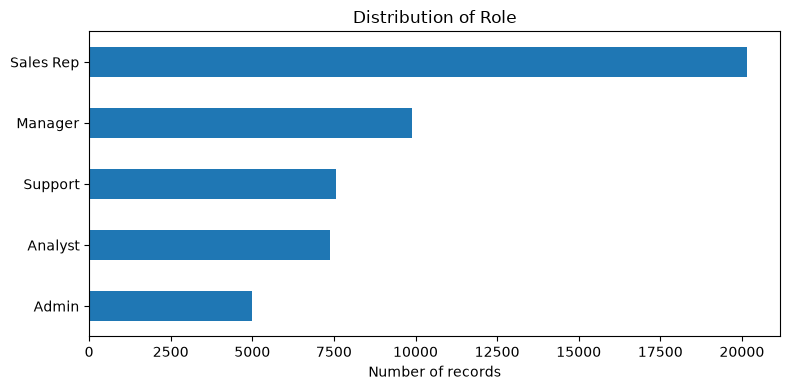

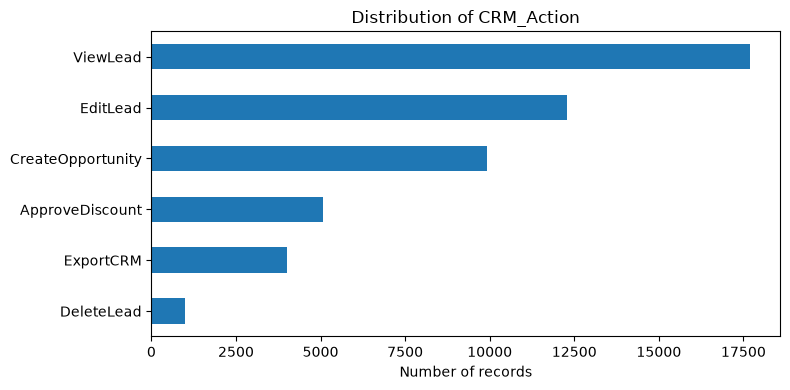

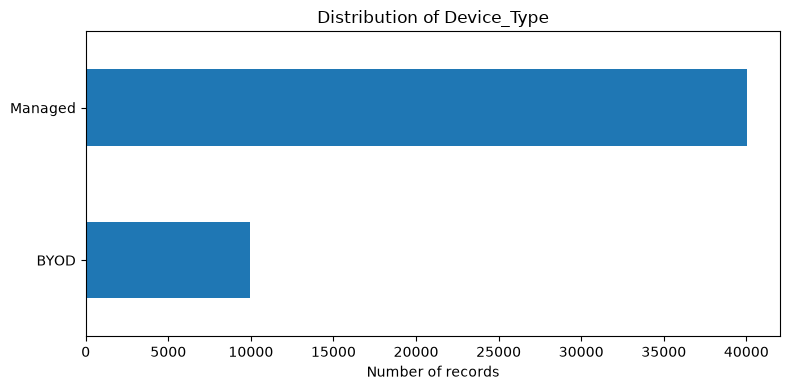

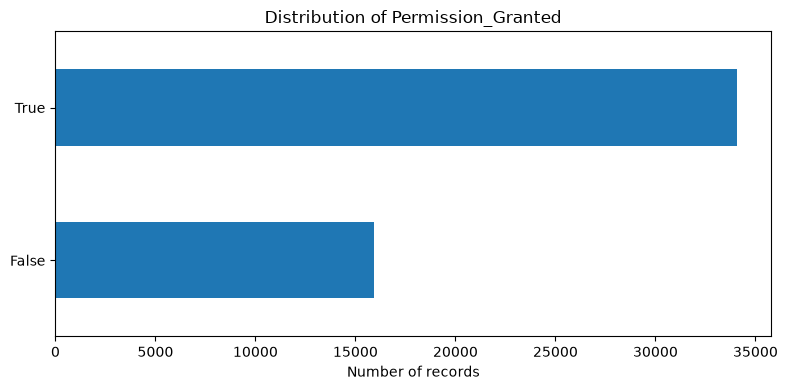

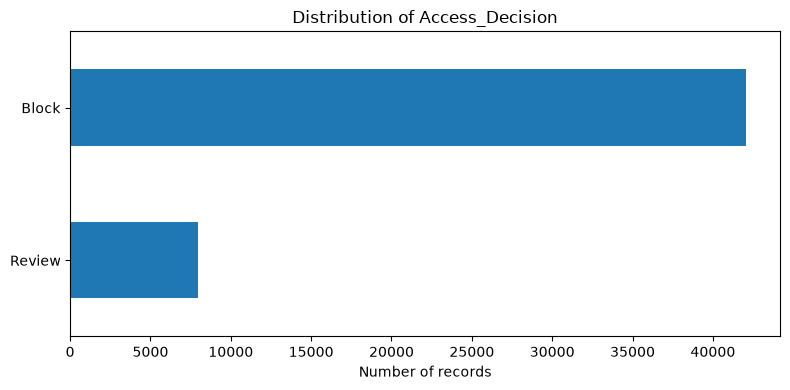

In [12]:
# 5.2 Main Categorical Distributions

plot_cols = ["Role", "CRM_Action", "Device_Type", "Permission_Granted", "Access_Decision"]

for col in plot_cols:
    counts = df[col].value_counts().sort_values()
    ax = counts.plot(kind="barh", figsize=(8, 4))
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("Number of records")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


# 6. Univariate Analysis — Behavior, Security, and Governance

The variables below represent access intensity, failed attempts, access time, data sensitivity, and governance/security scores.

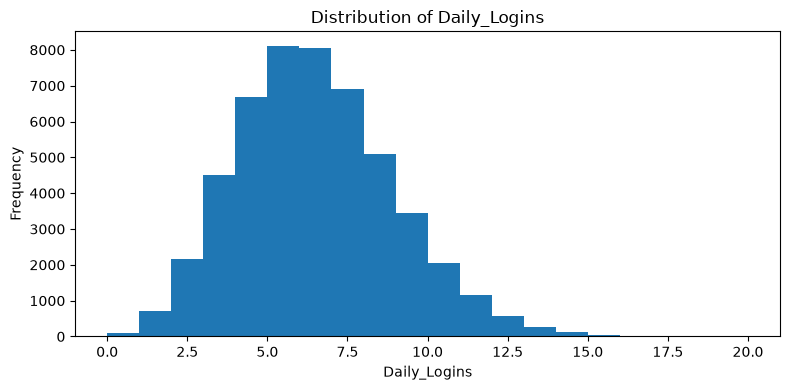

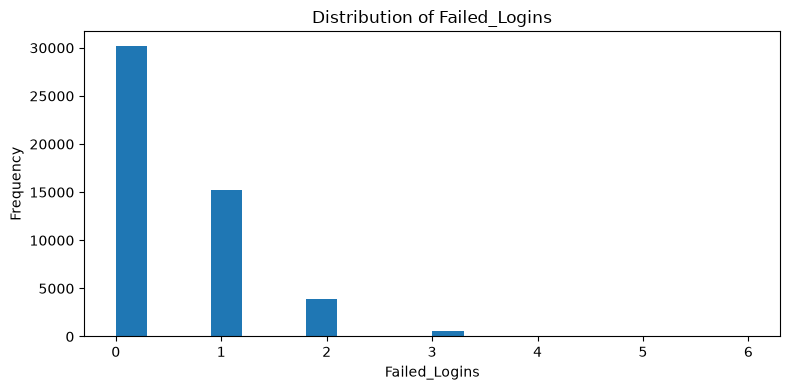

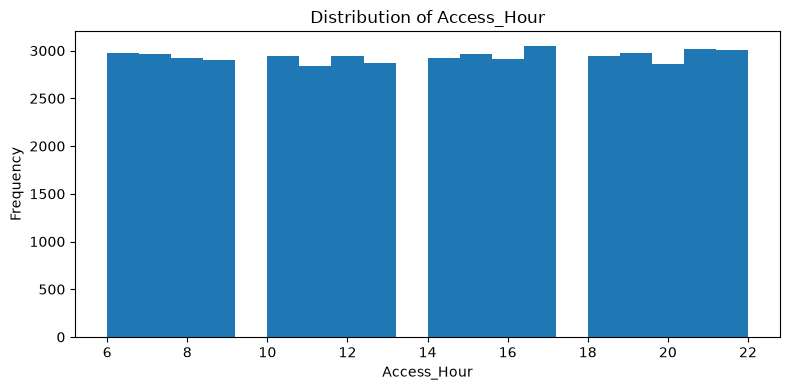

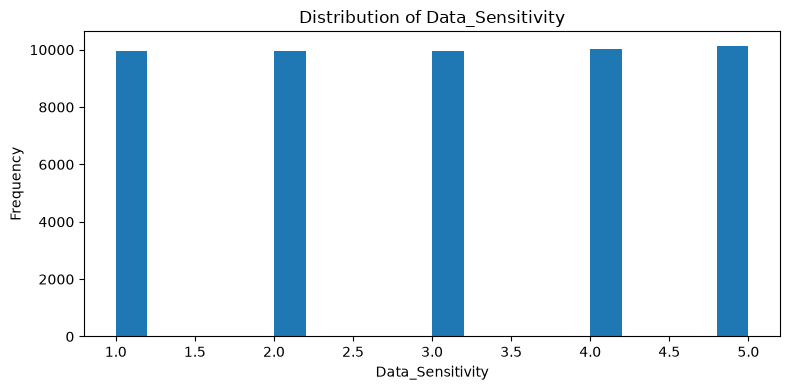

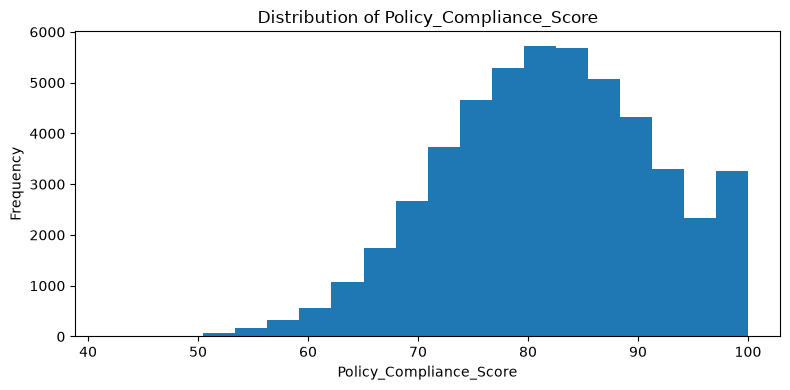

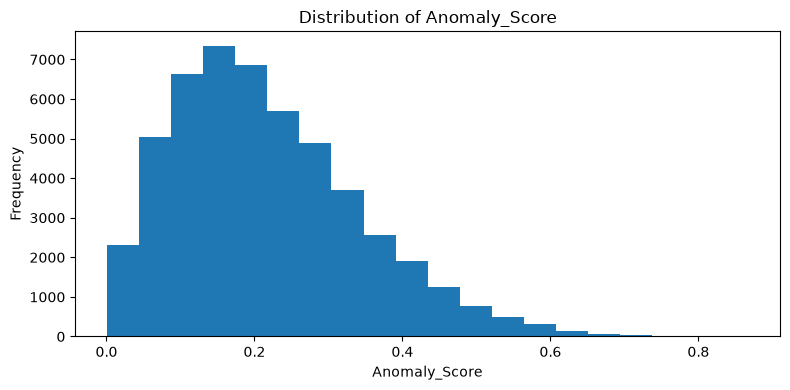

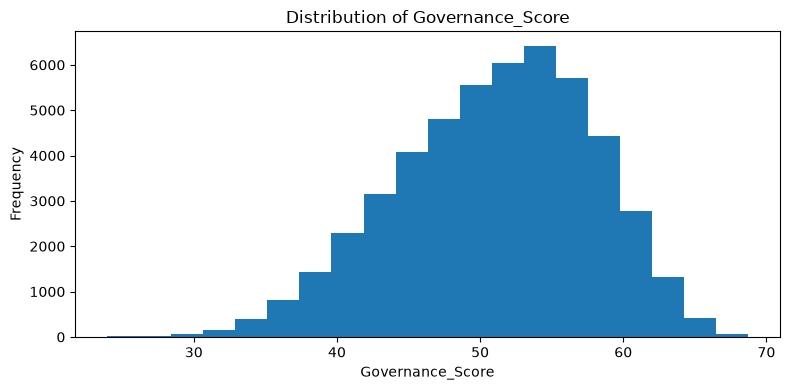

In [13]:
risk_numeric_cols = [
    "Daily_Logins",
    "Failed_Logins",
    "Access_Hour",
    "Data_Sensitivity",
    "Policy_Compliance_Score",
    "Anomaly_Score",
    "Governance_Score"
]

for col in risk_numeric_cols:
    ax = df[col].plot(kind="hist", bins=20, figsize=(8, 4))
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()


# 7. Outlier and Extreme Value Analysis

The goal of this section is **not** to automatically remove extreme values.

In a security context, an extreme value may represent one of the most relevant events for investigation.

### Study Note — IQR Method

The `iqr_summary()` function used below is **not a built-in pandas function**. It is a custom function created to summarize potential outliers using the **Interquartile Range (IQR)** method.

The main pandas method used inside the function is `Series.quantile()`, which is used to calculate the first quartile (`Q1`, 25th percentile) and third quartile (`Q3`, 75th percentile).

The interquartile range is calculated as:

`IQR = Q3 - Q1`

Potential outliers are identified using:

`Lower Bound = Q1 - 1.5 × IQR`

`Upper Bound = Q3 + 1.5 × IQR`

Values outside these limits are flagged as potential outliers. In this CRM governance project, however, unusual observations should **not** be automatically removed because they may represent relevant security events rather than data quality problems.

**Further study**
- pandas documentation: `Series.quantile()`
- statistical concepts: quartiles, IQR, boxplots, and outlier detection

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_27264\3092748694.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


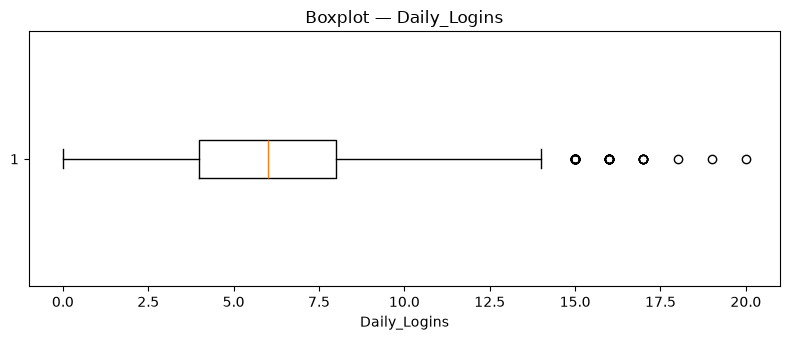

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_27264\3092748694.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


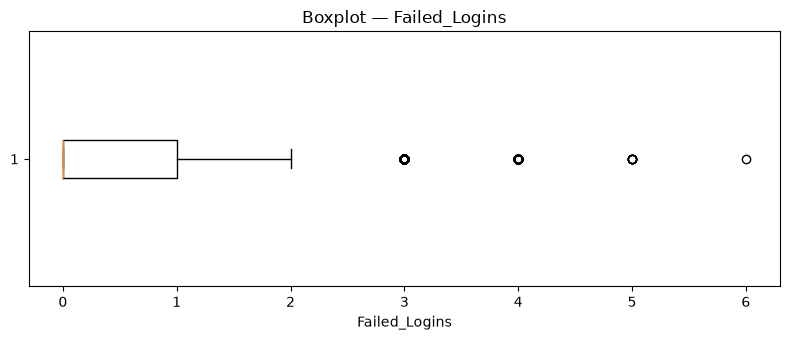

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_27264\3092748694.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


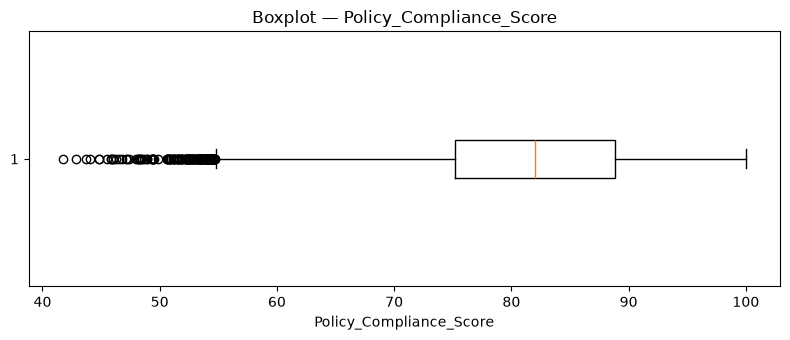

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_27264\3092748694.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


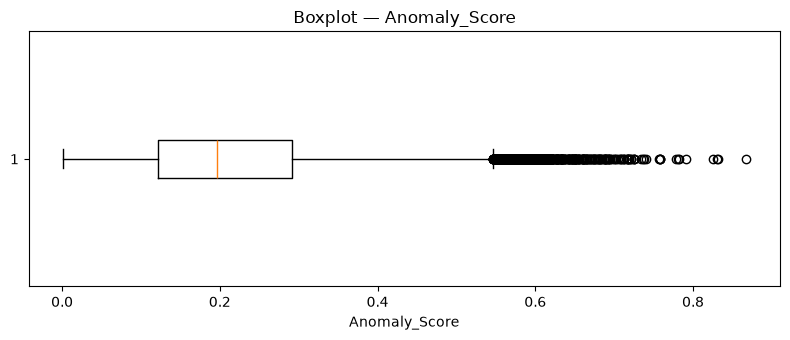

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_27264\3092748694.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


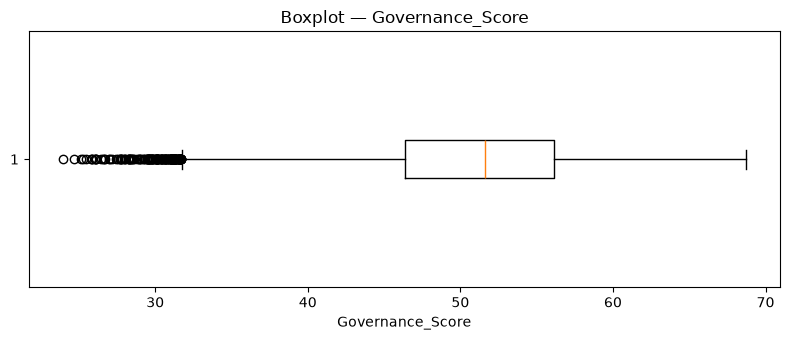

In [14]:
# 7.1 Boxplots

for col in [
    "Daily_Logins",
    "Failed_Logins",
    "Policy_Compliance_Score",
    "Anomaly_Score",
    "Governance_Score"
]:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.boxplot(df[col].dropna(), vert=False)
    ax.set_title(f"Boxplot — {col}")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()


In [15]:
# 7.2 IQR-Based Potential Outlier Detection

def iqr_summary(data, columns):
    rows = []

    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_count = ((data[col] < lower) | (data[col] > upper)).sum()

        rows.append({
            "Variable": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Potential_Outliers": outlier_count,
            "Outlier_%": outlier_count / len(data) * 100
        })

    return pd.DataFrame(rows)

display(
    iqr_summary(
        df,
        [
            "Daily_Logins",
            "Failed_Logins",
            "Policy_Compliance_Score",
            "Anomaly_Score",
            "Governance_Score"
        ]
    ).round(3)
)


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Potential_Outliers,Outlier_%
0,Daily_Logins,4.00,8.00,4.00,-2.00,14.00,58,0.12
1,Failed_Logins,0.00,1.00,1.00,-1.50,2.50,706,1.41
2,Policy_Compliance_Score,75.17,88.80,13.63,54.73,109.25,160,0.32
3,Anomaly_Score,0.12,0.29,0.17,-0.13,0.55,692,1.38
4,Governance_Score,46.36,56.12,9.76,31.71,70.76,153,0.31


# 8. Target Variable Analysis — Access Decision

A binary flag is created exclusively to simplify block-rate calculations.

- `1` = Block
- `0` = Review

In [16]:
df_eda = df.copy()

df_eda["Is_Blocked"] = df_eda["Access_Decision"].eq("Block").astype(int)

decision_summary = (
    df_eda["Access_Decision"]
    .value_counts()
    .to_frame("Count")
    .assign(Percentage=lambda x: (x["Count"] / len(df_eda) * 100).round(2))
)

display(decision_summary)


,Count,Percentage
Access_Decision,,
Block,42072,84.14
Review,7928,15.86


# 9. Permission Granted vs. Access Decision

One of the central hypotheses of this project is that **functional permission and contextual access approval are different concepts**.

This section evaluates their direct relationship.

In [17]:
permission_decision = pd.crosstab(
    df_eda["Permission_Granted"],
    df_eda["Access_Decision"],
    margins=True
)

permission_decision_pct = pd.crosstab(
    df_eda["Permission_Granted"],
    df_eda["Access_Decision"],
    normalize="index"
).mul(100).round(2)

display(permission_decision)
display(permission_decision_pct)


Access_Decision,Block,Review,All
Permission_Granted,,,
False,15929,2,15931
True,26143,7926,34069
All,42072,7928,50000


Access_Decision,Block,Review
Permission_Granted,,
False,99.99,0.01
True,76.74,23.26


# 10. Access Block Rate by Dimension

Because `Is_Blocked` is binary, its group-level mean directly represents the block rate.

In [18]:
def risk_group_summary(data, column):
    return (
        data.groupby(column)
        .agg(
            Records=("Is_Blocked", "size"),
            Block_Rate=("Is_Blocked", "mean"),
            Avg_Anomaly=("Anomaly_Score", "mean"),
            Avg_Compliance=("Policy_Compliance_Score", "mean"),
            Avg_Governance=("Governance_Score", "mean")
        )
        .assign(Block_Rate=lambda x: x["Block_Rate"] * 100)
        .sort_values("Block_Rate", ascending=False)
        .round(2)
    )

dimensions = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type",
    "Data_Sensitivity",
    "Failed_Logins",
    "Permission_Granted"
]

for col in dimensions:
    print(f"\n### {col}")
    display(risk_group_summary(df_eda, col))



### Role


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Role,,,,,
Analyst,7389,87.43,0.22,81.96,49.71
Support,7566,87.30,0.22,81.85,49.79
Sales Rep,20159,87.21,0.22,81.83,49.74
Manager,9904,76.76,0.22,81.88,54.05
Admin,4982,76.76,0.22,81.83,54.23



### Region


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Region,,,,,
East,12466,84.31,0.22,81.86,51.02
South,12507,84.26,0.22,81.80,51.04
West,12450,84.10,0.22,81.89,51.06
North,12577,83.90,0.22,81.89,51.06



### Lead_Source


...

,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Data_Sensitivity,,,,,
5,10134,91.94,0.21,82.02,49.17
4,10023,89.03,0.22,81.80,49.99
3,9941,85.12,0.22,81.82,51.07
2,9951,79.26,0.22,81.96,52.12
1,9951,75.20,0.22,81.71,52.93



### Failed_Logins


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Failed_Logins,,,,,
6,1,100.00,0.10,82.23,46.34
5,6,100.00,0.15,74.86,43.01
4,80,100.00,0.20,81.37,43.29
3,619,99.19,0.22,81.72,46.21
2,3896,94.79,0.21,81.86,48.06
1,15191,88.88,0.22,81.92,50.07
0,30207,80.03,0.22,81.84,52.04



### Permission_Granted


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Permission_Granted,,,,,
False,15931,99.99,0.22,81.92,44.28
True,34069,76.74,0.22,81.83,54.21


# 11. Access Behavior by Hour

This section separates two different questions:

1. At what times does the highest volume of CRM access occur?
2. At what times is the block rate highest?

High access volume does not necessarily imply higher risk.

In [19]:
hourly_profile = (
    df_eda.groupby("Access_Hour")
    .agg(
        Accesses=("User_ID", "size"),
        Block_Rate=("Is_Blocked", "mean"),
        Avg_Anomaly=("Anomaly_Score", "mean"),
        Avg_Governance=("Governance_Score", "mean")
    )
)

hourly_profile["Block_Rate"] *= 100
display(hourly_profile.round(2))


,Accesses,Block_Rate,Avg_Anomaly,Avg_Governance
Access_Hour,,,,
6,2972,82.87,0.22,51.14
7,2968,84.43,0.21,50.97
8,2918,82.39,0.21,51.17
9,2901,83.76,0.22,50.99
10,2944,83.36,0.21,51.32
11,2839,85.17,0.22,50.98
12,2943,84.13,0.22,51.21
13,2873,85.42,0.21,50.80
14,2920,84.52,0.22,51.09


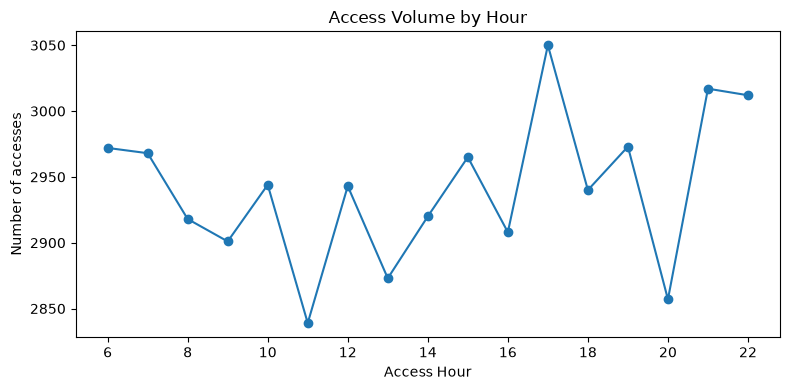

In [20]:
ax = hourly_profile["Accesses"].plot(kind="line", marker="o", figsize=(8, 4))
ax.set_title("Access Volume by Hour")
ax.set_xlabel("Access Hour")
ax.set_ylabel("Number of accesses")
plt.tight_layout()
plt.show()


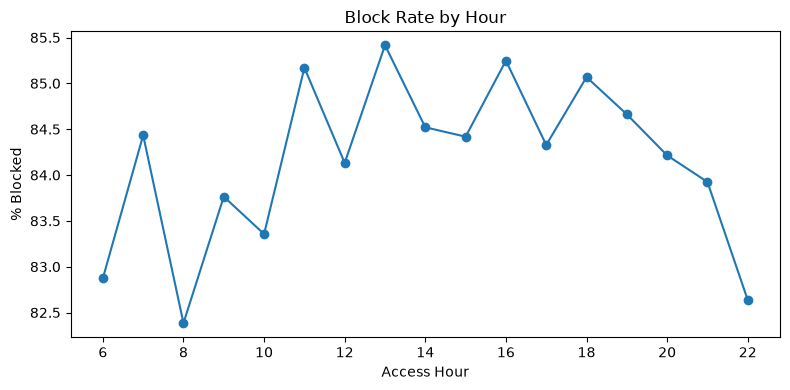

In [21]:
ax = hourly_profile["Block_Rate"].plot(kind="line", marker="o", figsize=(8, 4))
ax.set_title("Block Rate by Hour")
ax.set_xlabel("Access Hour")
ax.set_ylabel("% Blocked")
plt.tight_layout()
plt.show()


# 12. Data Sensitivity Analysis

This section evaluates whether higher `Data_Sensitivity` levels are associated with changes in access decisions and governance/security scores.

In [22]:
sensitivity_profile = (
    df_eda.groupby("Data_Sensitivity")
    .agg(
        Records=("User_ID", "size"),
        Block_Rate=("Is_Blocked", "mean"),
        Avg_Anomaly=("Anomaly_Score", "mean"),
        Avg_Compliance=("Policy_Compliance_Score", "mean"),
        Avg_Governance=("Governance_Score", "mean")
    )
)

sensitivity_profile["Block_Rate"] *= 100
display(sensitivity_profile.round(2))


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Data_Sensitivity,,,,,
1,9951,75.20,0.22,81.71,52.93
2,9951,79.26,0.22,81.96,52.12
3,9941,85.12,0.22,81.82,51.07
4,10023,89.03,0.22,81.80,49.99
5,10134,91.94,0.21,82.02,49.17


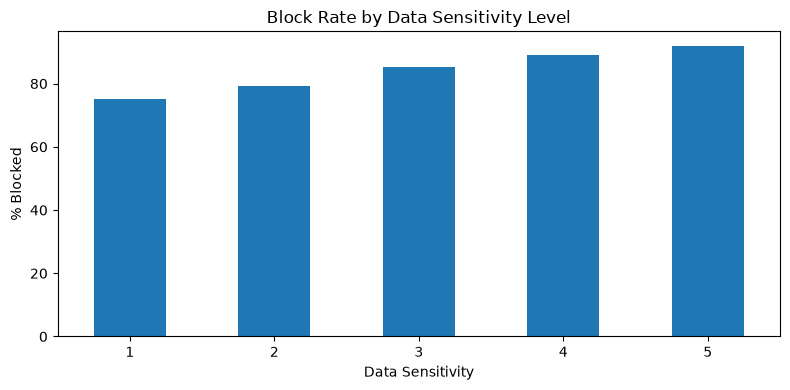

In [23]:
ax = sensitivity_profile["Block_Rate"].plot(kind="bar", figsize=(8, 4))
ax.set_title("Block Rate by Data Sensitivity Level")
ax.set_xlabel("Data Sensitivity")
ax.set_ylabel("% Blocked")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 13. Failed Login Analysis

This section evaluates whether `Failed_Logins` shows a consistent relationship with the access decision.

In [24]:
failed_login_profile = (
    df_eda.groupby("Failed_Logins")
    .agg(
        Records=("User_ID", "size"),
        Block_Rate=("Is_Blocked", "mean"),
        Avg_Anomaly=("Anomaly_Score", "mean"),
        Avg_Governance=("Governance_Score", "mean")
    )
)

failed_login_profile["Block_Rate"] *= 100
display(failed_login_profile.round(2))


,Records,Block_Rate,Avg_Anomaly,Avg_Governance
Failed_Logins,,,,
0,30207,80.03,0.22,52.04
1,15191,88.88,0.22,50.07
2,3896,94.79,0.21,48.06
3,619,99.19,0.22,46.21
4,80,100.00,0.20,43.29
5,6,100.00,0.15,43.01
6,1,100.00,0.10,46.34


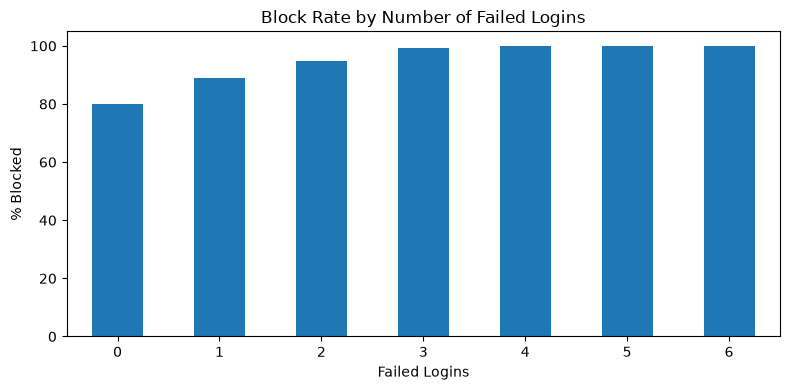

In [25]:
ax = failed_login_profile["Block_Rate"].plot(kind="bar", figsize=(8, 4))
ax.set_title("Block Rate by Number of Failed Logins")
ax.set_xlabel("Failed Logins")
ax.set_ylabel("% Blocked")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 14. CRM Action Analysis

Not all CRM actions carry the same operational risk.

This section examines action frequency, block rate, and average governance/security behavior without yet assigning formal risk levels.

,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
CRM_Action,,,,,
DeleteLead,987,97.16,0.22,82.22,45.25
ApproveDiscount,5081,93.43,0.22,81.89,47.05
ExportCRM,4019,93.08,0.21,82.10,47.41
EditLead,12293,92.91,0.22,81.82,47.23
CreateOpportunity,9924,76.77,0.22,81.77,54.22
ViewLead,17696,76.76,0.22,81.85,54.21


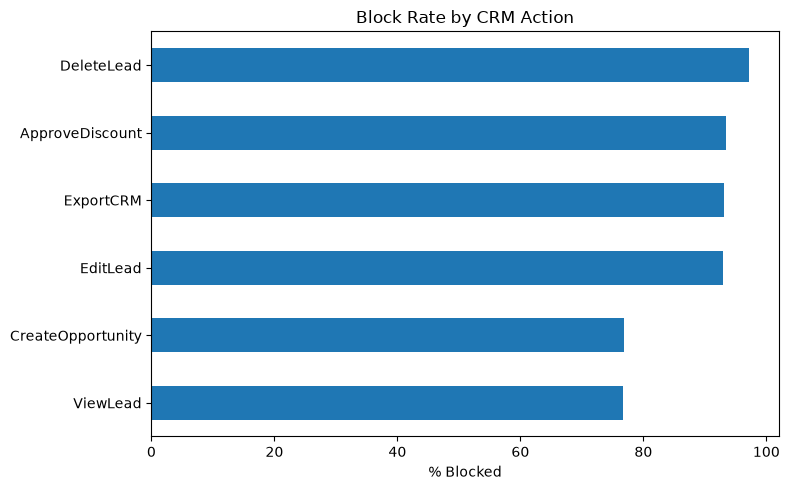

In [26]:
action_profile = risk_group_summary(df_eda, "CRM_Action")
display(action_profile)

ax = action_profile["Block_Rate"].sort_values().plot(kind="barh", figsize=(8, 5))
ax.set_title("Block Rate by CRM Action")
ax.set_xlabel("% Blocked")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


# 15. Device Type Analysis

Managed devices and BYOD devices are compared in terms of block rates and average governance/security scores.

In [27]:
device_profile = risk_group_summary(df_eda, "Device_Type")
display(device_profile)


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Device_Type,,,,,
BYOD,9965,90.70,0.28,81.84,49.52
Managed,40035,82.51,0.20,81.87,51.43


# 16. Bivariate Analysis and Pivot Tables

Univariate analysis evaluates isolated factors.

This section explores **interactions**, which are particularly important in contextual access-control environments.

In [28]:
# 16.1 Role × Device Type — Block Rate

role_device = pd.pivot_table(
    df_eda,
    values="Is_Blocked",
    index="Role",
    columns="Device_Type",
    aggfunc="mean"
).mul(100).round(2)

display(role_device)


Device_Type,BYOD,Managed
Role,,
Admin,85.96,74.37
Analyst,92.55,86.15
Manager,86.67,74.26
Sales Rep,92.59,85.89
Support,92.46,86.04


In [29]:
# 16.2 Role × CRM Action — Block Rate

role_action = pd.pivot_table(
    df_eda,
    values="Is_Blocked",
    index="Role",
    columns="CRM_Action",
    aggfunc="mean"
).mul(100).round(2)

display(role_action)


CRM_Action,ApproveDiscount,CreateOpportunity,DeleteLead,EditLead,ExportCRM,ViewLead
Role,,,,,,
Admin,74.85,77.05,69.23,75.16,80.70,77.75
Analyst,100.00,75.14,100.00,100.00,100.00,78.31
Manager,77.54,76.13,100.00,77.23,75.72,75.60
Sales Rep,100.00,77.14,100.00,99.98,100.00,76.54
Support,100.00,78.01,100.00,99.95,100.00,76.73


In [30]:
# 16.3 CRM Action × Data Sensitivity — Block Rate

action_sensitivity = pd.pivot_table(
    df_eda,
    values="Is_Blocked",
    index="CRM_Action",
    columns="Data_Sensitivity",
    aggfunc="mean"
).mul(100).round(2)

display(action_sensitivity)


Data_Sensitivity,1,2,3,4,5
CRM_Action,,,,,
ApproveDiscount,90.05,92.00,94.83,94.74,95.40
CreateOpportunity,62.66,70.40,77.52,84.18,88.71
DeleteLead,94.74,96.43,97.00,98.39,99.49
EditLead,89.51,90.46,93.17,94.83,96.42
ExportCRM,90.24,89.70,93.42,95.72,96.46
ViewLead,63.59,69.45,78.62,83.88,88.21


In [31]:
# 16.4 Permission × Data Sensitivity — Block Rate

permission_sensitivity = pd.pivot_table(
    df_eda,
    values="Is_Blocked",
    index="Permission_Granted",
    columns="Data_Sensitivity",
    aggfunc="mean"
).mul(100).round(2)

display(permission_sensitivity)


Data_Sensitivity,1,2,3,4,5
Permission_Granted,,,,,
False,99.94,100.00,100.00,100.00,100.00
True,63.28,69.78,78.23,83.90,88.16


In [32]:
# 16.5 Permission × Device Type — Block Rate

permission_device = pd.pivot_table(
    df_eda,
    values="Is_Blocked",
    index="Permission_Granted",
    columns="Device_Type",
    aggfunc="mean"
).mul(100).round(2)

display(permission_device)


Device_Type,BYOD,Managed
Permission_Granted,,
False,100.00,99.98
True,86.38,74.33


In [33]:
# 16.6 Governance Score by Role and Device Type

role_device_governance = pd.pivot_table(
    df_eda,
    values="Governance_Score",
    index="Role",
    columns="Device_Type",
    aggfunc="mean"
).round(2)

display(role_device_governance)


Device_Type,BYOD,Managed
Role,,
Admin,52.92,54.57
Analyst,48.25,50.08
Manager,52.34,54.48
Sales Rep,48.24,50.11
Support,48.09,50.21


# 17. Daily Logins vs. Failed Logins

A high number of logins may be normal for a particular role. Combining login volume with failed attempts provides additional behavioral context.

In [34]:
login_interaction = pd.pivot_table(
    df_eda,
    values="Is_Blocked",
    index="Daily_Logins",
    columns="Failed_Logins",
    aggfunc="mean"
).mul(100).round(2)

display(login_interaction)


Failed_Logins,0,1,2,3,4,5,6
Daily_Logins,,,,,,,
0,72.13,86.67,100.00,100.00,100.00,NaN,NaN
1,80.29,88.66,93.62,100.00,100.00,NaN,NaN
2,79.97,90.53,95.32,100.00,100.00,NaN,NaN
3,80.26,89.14,91.55,100.00,100.00,100.00,NaN
4,80.54,88.47,94.46,100.00,100.00,100.00,NaN
5,80.51,88.62,95.76,99.09,100.00,NaN,NaN
6,79.62,88.16,94.40,97.67,100.00,100.00,NaN
7,79.25,88.91,93.66,98.61,100.00,100.00,100.00
8,79.23,88.77,95.94,98.63,100.00,NaN,NaN


# 18. Risk Scores vs. Access Decision

This section compares `Policy_Compliance_Score`, `Anomaly_Score`, and `Governance_Score` across access outcomes.

In [35]:
score_cols = [
    "Policy_Compliance_Score",
    "Anomaly_Score",
    "Governance_Score"
]

score_summary = (
    df_eda.groupby("Access_Decision")[score_cols]
    .agg(["mean", "median", "std", "min", "max"])
)

display(score_summary.round(3))


Policy_Compliance_Score                           \
                                   mean median  std   min    max   
Access_Decision                                                    
Block                             80.17  80.23 9.26 41.74 100.00   
Review                            90.84  91.10 6.43 70.46 100.00   

                Anomaly_Score                       Governance_Score         \
                         mean median  std  min  max             mean median   
Access_Decision                                                               
Block                    0.23   0.22 0.12 0.00 0.87            49.24  50.12   
Review                   0.13   0.12 0.07 0.00 0.43            60.60  60.14   

                                  
                 std   min   max  
Access_Decision                   
Block           5.83 23.95 58.00  
Review          2.02 58.00 68.71

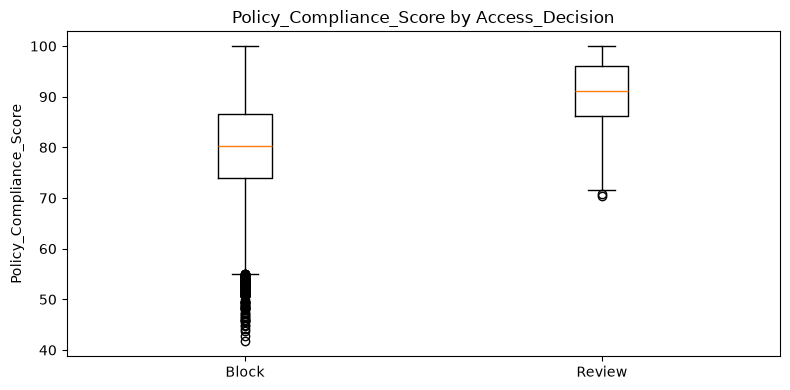

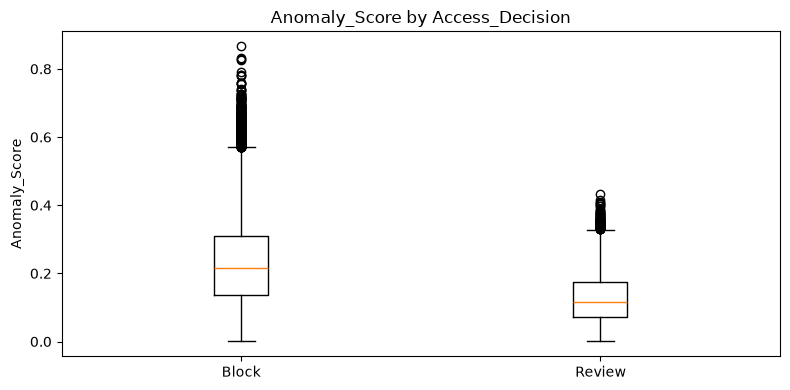

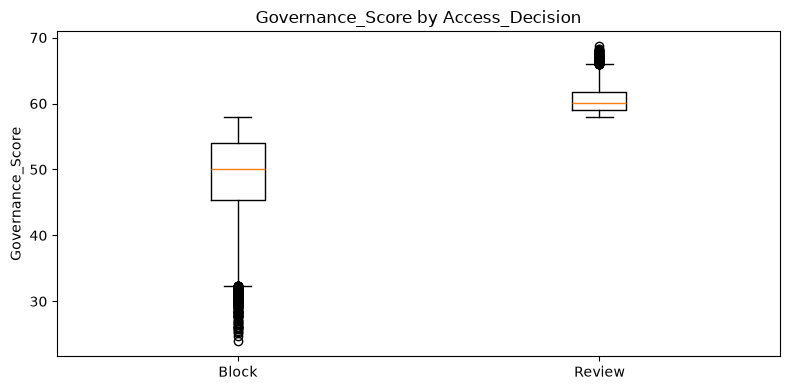

In [37]:
for col in score_cols:
    groups = [
        df_eda.loc[df_eda["Access_Decision"] == decision, col]
        for decision in df_eda["Access_Decision"].unique()
    ]
    labels = df_eda["Access_Decision"].unique()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot(groups, tick_labels=labels)
    ax.set_title(f"{col} by Access_Decision")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()


# 19. Anomaly Score vs. Policy Compliance Score

This relationship helps evaluate whether anomalous behavior and policy compliance act independently or jointly.

A sample is used only for visualization to reduce overplotting.

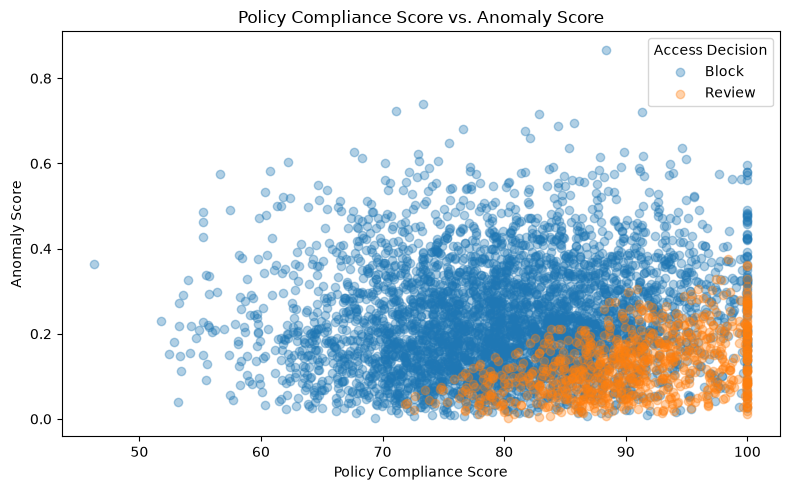

In [38]:
sample = df_eda.sample(min(5000, len(df_eda)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))

for decision in sample["Access_Decision"].unique():
    subset = sample[sample["Access_Decision"] == decision]
    ax.scatter(
        subset["Policy_Compliance_Score"],
        subset["Anomaly_Score"],
        alpha=0.35,
        label=decision
    )

ax.set_title("Policy Compliance Score vs. Anomaly Score")
ax.set_xlabel("Policy Compliance Score")
ax.set_ylabel("Anomaly Score")
ax.legend(title="Access Decision")
plt.tight_layout()
plt.show()


# 20. Correlation Analysis

Correlation helps identify linear relationships among numerical variables, but it should not be interpreted as causation.

`User_ID` is excluded because it is only an identifier.

In [39]:
corr_cols = [
    "Daily_Logins",
    "Failed_Logins",
    "Access_Hour",
    "Data_Sensitivity",
    "Policy_Compliance_Score",
    "Anomaly_Score",
    "Governance_Score",
    "Is_Blocked"
]

corr = df_eda[corr_cols].corr()
display(corr.round(3))


,Daily_Logins,Failed_Logins,Access_Hour,Data_Sensitivity,Policy_Compliance_Score,Anomaly_Score,Governance_Score,Is_Blocked
Daily_Logins,1.00,0.00,0.00,0.01,0.00,-0.00,0.00,0.00
Failed_Logins,0.00,1.00,-0.00,0.00,0.00,-0.00,-0.21,0.15
Access_Hour,0.00,-0.00,1.00,-0.01,0.00,0.01,-0.00,0.01
Data_Sensitivity,0.01,0.00,-0.01,1.00,0.01,-0.01,-0.20,0.17
Policy_Compliance_Score,0.00,0.00,0.00,0.01,1.00,0.00,0.49,-0.40
Anomaly_Score,-0.00,-0.00,0.01,-0.01,0.00,1.00,-0.45,0.31
Governance_Score,0.00,-0.21,-0.00,-0.20,0.49,-0.45,1.00,-0.61
Is_Blocked,0.00,0.15,0.01,0.17,-0.40,0.31,-0.61,1.00


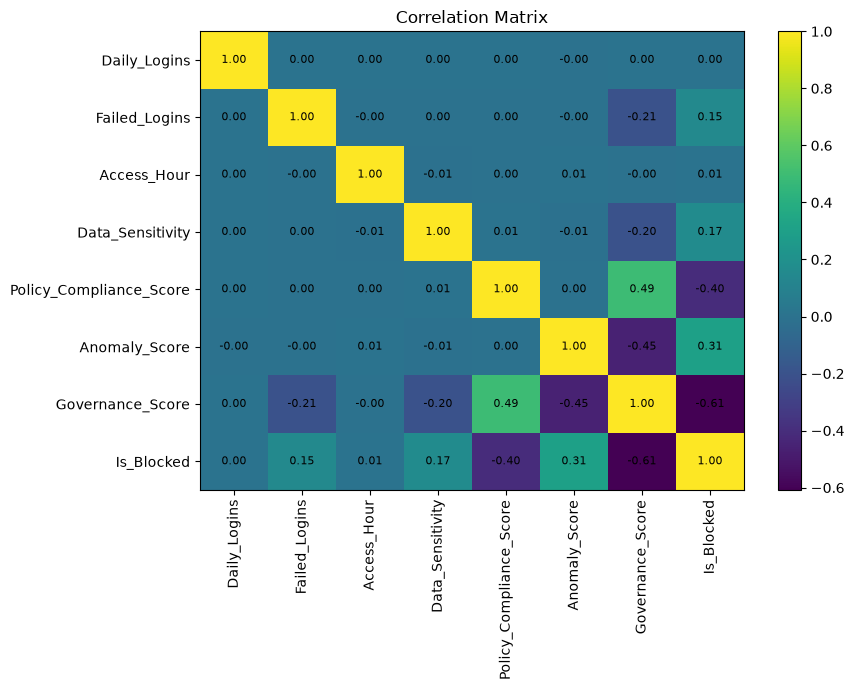

In [40]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

fig.colorbar(im, ax=ax)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


# 21. Exploratory Risk Flags

The flags below are created **only for exploratory purposes**.

They do not represent an official governance policy, a legal requirement, or a definitive access-control rule.

- High sensitivity: levels 4 or 5.
- Failed login: at least one failed attempt.
- BYOD: non-managed device.
- High anomaly: 90th percentile of the observed anomaly-score distribution.
- Exploratory critical action: `ExportCRM`, `DeleteLead`, or `ApproveDiscount`.
- Edge-hour access: observations near the beginning or end of the access-hour window present in the dataset.

In [41]:
df_eda["High_Sensitivity_Flag"] = df_eda["Data_Sensitivity"].ge(4)
df_eda["Failed_Login_Flag"] = df_eda["Failed_Logins"].gt(0)
df_eda["BYOD_Flag"] = df_eda["Device_Type"].eq("BYOD")

anomaly_p90 = df_eda["Anomaly_Score"].quantile(0.90)
df_eda["High_Anomaly_Flag"] = df_eda["Anomaly_Score"].ge(anomaly_p90)

exploratory_critical_actions = [
    "ExportCRM",
    "DeleteLead",
    "ApproveDiscount"
]

df_eda["Critical_Action_Flag"] = df_eda["CRM_Action"].isin(
    exploratory_critical_actions
)

min_hour = df_eda["Access_Hour"].min()
max_hour = df_eda["Access_Hour"].max()

df_eda["Edge_Hour_Flag"] = (
    df_eda["Access_Hour"].le(min_hour + 1) |
    df_eda["Access_Hour"].ge(max_hour - 1)
)

risk_flags = [
    "High_Sensitivity_Flag",
    "Failed_Login_Flag",
    "BYOD_Flag",
    "High_Anomaly_Flag",
    "Critical_Action_Flag",
    "Edge_Hour_Flag"
]

df_eda["Exploratory_Risk_Factors"] = df_eda[risk_flags].sum(axis=1)

print(f"90th percentile of Anomaly_Score: {anomaly_p90:.3f}")
print(f"Observed access-hour window: {min_hour}h–{max_hour}h")

display(
    df_eda[
        risk_flags + ["Exploratory_Risk_Factors"]
    ].head()
)


90th percentile of Anomaly_Score: 0.389
Observed access-hour window: 6h–22h


,High_Sensitivity_Flag,Failed_Login_Flag,BYOD_Flag,High_Anomaly_Flag,Critical_Action_Flag,Edge_Hour_Flag,Exploratory_Risk_Factors
0,True,True,False,False,False,False,2
1,True,True,False,True,False,False,3
2,False,True,False,False,False,False,1
3,False,False,False,False,False,False,0
4,False,True,False,False,False,False,1


# 22. Combined Exploratory Risk Factors

This section evaluates whether a higher number of exploratory risk factors is associated with a higher block rate.

The goal is to understand interactions, not to define a final risk score.

In [42]:
risk_factor_profile = (
    df_eda.groupby("Exploratory_Risk_Factors")
    .agg(
        Records=("User_ID", "size"),
        Block_Rate=("Is_Blocked", "mean"),
        Avg_Anomaly=("Anomaly_Score", "mean"),
        Avg_Compliance=("Policy_Compliance_Score", "mean"),
        Avg_Governance=("Governance_Score", "mean")
    )
)

risk_factor_profile["Block_Rate"] *= 100
display(risk_factor_profile.round(2))


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Exploratory_Risk_Factors,,,,,
0,7967,65.96,0.18,81.71,55.05
1,17819,81.01,0.19,81.91,52.52
2,15624,90.18,0.22,81.94,49.93
3,6698,95.86,0.27,81.76,47.03
4,1662,98.98,0.33,81.78,44.06
5,218,98.62,0.40,82.26,41.51
6,12,100.00,0.46,82.88,37.02


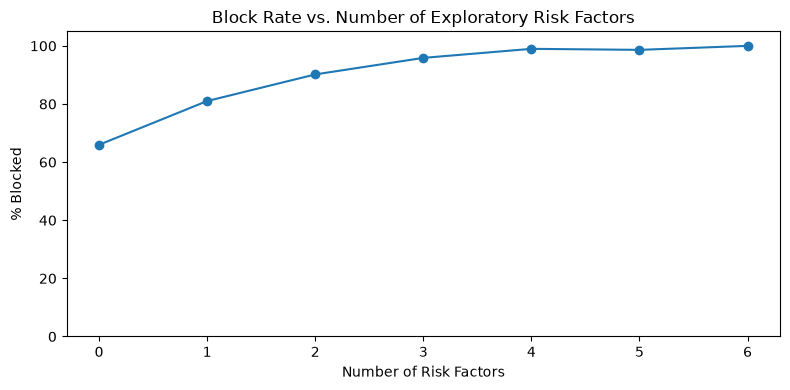

In [43]:
ax = risk_factor_profile["Block_Rate"].plot(
    kind="line",
    marker="o",
    figsize=(8, 4)
)

ax.set_title("Block Rate vs. Number of Exploratory Risk Factors")
ax.set_xlabel("Number of Risk Factors")
ax.set_ylabel("% Blocked")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()


# 23. High-Attention Access Profiles

This section selects records that:

- have functional permission;
- present multiple exploratory risk factors.

This helps illustrate why **having permission** and **receiving contextual access approval** are different governance questions.

In [44]:
high_attention = df_eda[
    (df_eda["Permission_Granted"] == True) &
    (df_eda["Exploratory_Risk_Factors"] >= 3)
].copy()

print(
    f"Records with permission and at least 3 exploratory risk factors: "
    f"{len(high_attention):,}"
)

if len(high_attention) > 0:
    print(
        f"Block rate in this group: "
        f"{high_attention['Is_Blocked'].mean() * 100:.2f}%"
    )

display(
    high_attention[
        [
            "User_ID",
            "Role",
            "CRM_Action",
            "Device_Type",
            "Data_Sensitivity",
            "Daily_Logins",
            "Failed_Logins",
            "Access_Hour",
            "Policy_Compliance_Score",
            "Anomaly_Score",
            "Permission_Granted",
            "Governance_Score",
            "Access_Decision",
            "Exploratory_Risk_Factors"
        ]
    ]
    .sort_values(
        ["Exploratory_Risk_Factors", "Anomaly_Score"],
        ascending=False
    )
    .head(20)
)


Records with permission and at least 3 exploratory risk factors: 4,667
Block rate in this group: 93.64%


,User_ID,Role,CRM_Action,Device_Type,Data_Sensitivity,Daily_Logins,Failed_Logins,Access_Hour,Policy_Compliance_Score,Anomaly_Score,Permission_Granted,Governance_Score,Access_Decision,Exploratory_Risk_Factors
606,607,Admin,ApproveDiscount,BYOD,5,8,1,7,71.55,0.53,True,39.88,Block,6
19505,19506,Manager,ApproveDiscount,BYOD,4,6,1,7,75.27,0.47,True,43.55,Block,6
6858,6859,Support,CreateOpportunity,BYOD,4,9,1,7,86.82,0.70,True,41.97,Block,5
35824,35825,Manager,ExportCRM,BYOD,4,8,2,15,76.25,0.61,True,38.34,Block,5
18236,18237,Manager,ExportCRM,Managed,4,8,1,21,84.99,0.61,True,43.57,Block,5
34755,34756,Manager,ApproveDiscount,BYOD,5,3,1,16,84.18,0.60,True,42.38,Block,5
33253,33254,Admin,ApproveDiscount,BYOD,4,2,1,13,91.93,0.60,True,46.24,Block,5
16423,16424,Analyst,ViewLead,BYOD,5,8,3,21,76.92,0.57,True,36.78,Block,5
8976,8977,Manager,ExportCRM,BYOD,5,6,1,17,90.33,0.56,True,45.52,Block,5
19187,19188,Manager,CreateOpportunity,BYOD,4,9,1,6,59.84,0.56,True,35.85,Block,5


# 24. Consolidated Risk Summary

This table summarizes the main analytical dimensions in a format that can later support KPI definition and Power BI modeling.

In [45]:
def consolidated_dimension_summary(data, dimension):
    result = (
        data.groupby(dimension)
        .agg(
            Records=("User_ID", "size"),
            Block_Rate=("Is_Blocked", "mean"),
            Avg_Anomaly=("Anomaly_Score", "mean"),
            Avg_Compliance=("Policy_Compliance_Score", "mean"),
            Avg_Governance=("Governance_Score", "mean")
        )
        .reset_index()
        .rename(columns={dimension: "Category"})
    )

    result.insert(0, "Dimension", dimension)
    result["Block_Rate"] *= 100

    return result

summary_dimensions = [
    "Role",
    "CRM_Action",
    "Device_Type",
    "Data_Sensitivity",
    "Failed_Logins",
    "Region",
    "Lead_Source"
]

risk_summary = pd.concat(
    [
        consolidated_dimension_summary(df_eda, dimension)
        for dimension in summary_dimensions
    ],
    ignore_index=True
)

display(
    risk_summary
    .sort_values(["Dimension", "Block_Rate"], ascending=[True, False])
    .round(2)
)


,Dimension,Category,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
7,CRM_Action,DeleteLead,987,97.16,0.22,82.22,45.25
5,CRM_Action,ApproveDiscount,5081,93.43,0.22,81.89,47.05
9,CRM_Action,ExportCRM,4019,93.08,0.21,82.10,47.41
8,CRM_Action,EditLead,12293,92.91,0.22,81.82,47.23
6,CRM_Action,CreateOpportunity,9924,76.77,0.22,81.77,54.22
10,CRM_Action,ViewLead,17696,76.76,0.22,81.85,54.21
17,Data_Sensitivity,5,10134,91.94,0.21,82.02,49.17
16,Data_Sensitivity,4,10023,89.03,0.22,81.80,49.99
15,Data_Sensitivity,3,9941,85.12,0.22,81.82,51.07
14,Data_Sensitivity,2,9951,79.26,0.22,81.96,52.12


# 25. Evidence, Hypotheses, and EDA Limitations

After reviewing the results, findings should be separated into three categories.

### Observed Evidence
Relationships directly supported by the dataset.

Examples:
- block rate by permission status;
- block rate by data sensitivity;
- differences between device types;
- score variation across access decisions.

### Hypotheses
Patterns that require further investigation.

Examples:
- a specific CRM action may contribute more strongly to blocking;
- BYOD combined with high data sensitivity may increase risk;
- governance/security scores may be part of a composite decision rule.

### Proposed Governance Rules
These should only be defined in a later stage.

A relationship observed in this synthetic dataset does not automatically mean it should become a real-world security policy.

# 26. Summary of Findings

Complete this section after reviewing the outputs.

## 26.1 Data Quality
- Number of records:
- Number of columns:
- Missing values:
- Duplicate records:
- Domain inconsistencies:
- Additional observations:

## 26.2 Access Behavior
- Hour with the highest access volume:
- Hour with the highest block rate:
- Role with the highest access volume:
- Unusual behavioral patterns:

## 26.3 Governance
- Relationship between `Permission_Granted` and `Access_Decision`:
- Impact of `Data_Sensitivity`:
- Impact of `Device_Type`:
- CRM actions with the highest block rates:
- Relationship between `Governance_Score` and access decision:

## 26.4 Security
- Impact of `Failed_Logins`:
- Relationship between `Anomaly_Score` and access decision:
- Relationship between policy compliance and access decision:
- High-attention combinations:

## 26.5 Relevant Interactions
1.
2.
3.

## 26.6 Hypotheses to Validate
1.
2.
3.

# 27. Next Steps

After completing the EDA, the project can move to the following stages.

### Stage 2 — Explanatory Analysis
- quantify associations;
- investigate possible thresholds;
- identify which variables best explain `Access_Decision`;
- evaluate whether the decision-generation logic can be approximately reconstructed.

### Stage 3 — Governance Rules
- build a `Role × CRM_Action` access matrix;
- define internal sensitivity levels;
- separate role-based access control from contextual controls;
- document rules, exceptions, and rationale.

### Stage 4 — Analytical Data Model
- define the access fact table;
- create dimensions;
- prepare the analytical consumption layer;
- define KPIs and measures.

### Stage 5 — Power BI
- Governance Overview;
- Access Risk;
- Role & Permission;
- Sensitive Data Monitoring;
- Security & Anomalies.

### Optional Future Stage — Behavioral Access Segmentation
Clustering techniques may later be used to identify behavioral access profiles, but they are intentionally excluded from this initial EDA.